In [1]:
!pip install psycopg2-binary

In [2]:
!pip install clickhouse-connect

In [3]:
import pandas as pd
import numpy as np
import tabulate
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import psycopg2
from clickhouse_connect import get_client


In [4]:
pd.set_option('display.max_columns', None)

In [ ]:
ch_client = get_client(
    host="",
    port=8443,
    username="",
    password=""
)

In [ ]:
conn = psycopg2.connect(
    host="",
    database="",
    user="",
    password="",
    port=5432
)

CDS

In [7]:
cds_query = """
SELECT
  customerid
FROM data_science.cds
"""

cds_df = pd.read_sql(cds_query, conn)

/tmp/ipykernel_13394/2438996159.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cds_df = pd.read_sql(cds_query, conn)


In [8]:
cds_df.head()

,customerid
0,10
1,100000
2,100001
3,100002
4,100003


In [9]:
cds_df[cds_df["customerid"] == "5205"]

,customerid
30047,5205


In [10]:
cds_df.shape

(55326, 1)

In [11]:
cds_df.customerid.nunique()

51941

Account Status

In [12]:
accounts_mv_query='''
SELECT
  account_id,
  customerId AS customer_id,
  status AS current_account_status,
  accountType,
  updatedAt,
  companyRegion,
  createdAt AS account_created_at
  FROM marts.accounts_mv
'''
accounts_mv_df_ch=ch_client.query_df(accounts_mv_query)

In [13]:
# convert data types
cat_columns = ['customer_id', 'accountType', 'current_account_status', 'companyRegion']


accounts_mv_df_ch[cat_columns] = accounts_mv_df_ch[cat_columns].astype(str)

In [14]:
accounts_mv_df_ch.shape

(141903, 7)

In [15]:
# convert data types
cat_columns = ['customer_id', 'accountType']


accounts_mv_df_ch[cat_columns] = accounts_mv_df_ch[cat_columns].astype(str)

In [16]:
# Sort by customer_id and updated_at descending
accounts_mv_df_ch = accounts_mv_df_ch.sort_values(['customer_id', 'updatedAt'], ascending=[True, False])

# Drop duplicates, keeping the latest per customer_id
accounts_mv_df_ch = accounts_mv_df_ch.drop_duplicates(subset='customer_id', keep='first')

# Use Kenyan Account Only
accounts_mv_df_ch = accounts_mv_df_ch[accounts_mv_df_ch['companyRegion']=='kenya']

In [17]:
# accounts_mv_df_ch = accounts_mv_df_ch[~accounts_mv_df_ch['customer_id'].str.match(r'^(?=.*[A-Za-z])(?=.*\d)', na=False)]
accounts_mv_df_ch['customer_id'] = accounts_mv_df_ch['customer_id'].astype(int)

In [18]:
accounts_mv_df_ch.current_account_status.value_counts()

,count
current_account_status,
No Deposit,61129
Complete,19717
Current,7781
Repossession,7583
Arrears,7022
Full Deposit,2549
Refunded,2361
Write Off,1952
Pending Repossession,1449


In [19]:
# remove unnecessary columns
accounts_mv_df_ch = accounts_mv_df_ch.drop(['current_account_status', 'updatedAt', 'companyRegion'], axis=1)

In [20]:
accounts_mv_df_ch.shape

(115448, 4)

In [21]:
accounts_mv_df_ch.customer_id.nunique()

115448

In [22]:
accounts_mv_df_ch.head()

,account_id,customer_id,accountType,account_created_at
66017,35572,1,CASH,2022-04-26 17:28:30+03:00
53653,20932,10,PAYG,2020-01-09 11:38:37+03:00
36919,1129,100,PAYG,2021-10-02 22:41:39+03:00
48527,14842,1000,PAYG,2021-07-19 08:58:32+03:00
63874,33045,10000,PAYG,2021-08-19 20:54:11+03:00


In [23]:
accounts_mv_df_ch.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115448 entries, 66017 to 126973
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype                         
---  ------              --------------   -----                         
 0   account_id          115448 non-null  int32                         
 1   customer_id         115448 non-null  int64                         
 2   accountType         115448 non-null  object                        
 3   account_created_at  115448 non-null  datetime64[ns, Africa/Nairobi]
dtypes: datetime64[ns, Africa/Nairobi](1), int32(1), int64(1), object(1)
memory usage: 4.0+ MB


In [24]:
accounts_mv_df_ch.accountType.value_counts()

,count
accountType,
PAYG,100508
CASH,14580
ADDON,360


Credit History

In [25]:
credit_history_query = """
SELECT
  customer_id,
  country,
  account_id,
  account_type,
  installment_type,
  expected_date,
  expected_amount,
  final_amount_paid,
  final_paid_date,
  amount_due,
  days_late,
  total_balance,
  sync_timestamp
FROM data_science.agg_credit_history_v1
"""

credit_history_df = pd.read_sql(credit_history_query, conn)
credit_history_df['expected_date'] = pd.to_datetime(credit_history_df['expected_date'])
credit_history_df['final_paid_date'] = pd.to_datetime(credit_history_df['final_paid_date'])
credit_history_df['month'] = pd.to_datetime(credit_history_df['expected_date']).dt.to_period('M').dt.to_timestamp()

/tmp/ipykernel_13394/3580805632.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  credit_history_df = pd.read_sql(credit_history_query, conn)


In [26]:
credit_history_df.head()

,customer_id,country,account_id,account_type,installment_type,expected_date,expected_amount,final_amount_paid,final_paid_date,amount_due,days_late,total_balance,sync_timestamp,month
0,154519,kenya,151750,PAYG,installment,2026-12-20,3809.0,0.0,NaT,3809.0,0,39992.5,2026-03-11 11:14:06.760444,2026-12-01
1,154519,kenya,151750,PAYG,installment,2027-01-20,3809.0,0.0,NaT,3809.0,0,43801.5,2026-03-11 11:14:06.760444,2027-01-01
2,154519,kenya,151750,PAYG,installment,2027-02-20,3809.0,0.0,NaT,3809.0,0,47610.5,2026-03-11 11:14:06.760444,2027-02-01
3,154519,kenya,151750,PAYG,installment,2027-03-20,3809.0,0.0,NaT,3809.0,0,51419.5,2026-03-11 11:14:06.760444,2027-03-01
4,154519,kenya,151750,PAYG,installment,2027-04-20,3809.0,0.0,NaT,3809.0,0,55228.5,2026-03-11 11:14:06.760444,2027-04-01


In [ ]:
credit_history_df[credit_history_df['account_id']==57323]

In [ ]:
credit_history_df[credit_history_df['customer_id']==10]

In [ ]:
credit_history_df[credit_history_df['customer_id']==5205]

In [30]:
# installment_payments_query='''
# SELECT
#   id AS instalmentPaymentId,
#   accountId AS accountid,
#   instalmentScheduleId,
#   amtPaid AS amountpaid,
#   paidDate AS paiddate
#   FROM sunculture.installment_payment
# '''
# installment_payments_df=ch_client.query_df(installment_payments_query)

In [31]:
# installment_schedules_query='''
# SELECT
#   id AS instalmentScheduleId,
#   customerId AS customerid,
#   expectedAmount AS expectedamount,
#   expectedDate AS expecteddate,
#   FROM sunculture.installment_schedules
# '''
# installment_schedules_df=ch_client.query_df(installment_schedules_query)
# installment_schedules_df['month'] = pd.to_datetime(installment_schedules_df['month']).dt.to_period('M').dt.to_timestamp()

In [32]:
# installment_df = pd.merge(installment_payments_df, installment_schedules_df, on="instalmentScheduleId", how="left")

In [33]:
# credit_history_df = pd.merge(installment_payments_df, credit_history_df, on=['customerid', 'month'], how='left')

In [34]:
# credit_history_df = credit_history_df[(credit_history_df['country']=='kenya') & (credit_history_df['expected_date']<'2026-03-01')]

In [35]:
credit_history_df.shape

(1196565, 14)

In [36]:
credit_history_df.customer_id.nunique()

32475

In [37]:
# drop columns where everything is null - will not work long term, but can't be used at the moment since none of the values can be inferred
credit_history_df = credit_history_df.dropna(axis=1, how='all')

# convert empty strings to null - also not ideal as empty could mean 0 or no
credit_history_df = credit_history_df.replace('', np.nan)


In [38]:
# remove unnecessary columns
credit_history_df = credit_history_df.drop(['sync_timestamp'], axis=1)

In [39]:
# convert data types
float_columns = ['expected_amount', 'final_amount_paid', 'amount_due', 'total_balance']

cat_columns = ['customer_id', 'month', 'is_fully_paid', 'country', 'account_id', 'account_type', 'installment_type']


credit_history_df[float_columns] = credit_history_df[float_columns].astype(float)

In [40]:
credit_history_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1196565 entries, 0 to 1196564
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   customer_id        1196565 non-null  int64         
 1   country            1196565 non-null  object        
 2   account_id         1196565 non-null  int64         
 3   account_type       1196565 non-null  object        
 4   installment_type   1196564 non-null  object        
 5   expected_date      1196565 non-null  datetime64[ns]
 6   expected_amount    1196565 non-null  float64       
 7   final_amount_paid  1196565 non-null  float64       
 8   final_paid_date    639047 non-null   datetime64[ns]
 9   amount_due         1196565 non-null  float64       
 10  days_late          1196565 non-null  int64         
 11  total_balance      1196565 non-null  float64       
 12  month              1196565 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float

In [41]:
credit_history_df.month.max()

Timestamp('2029-03-01 00:00:00')

In [42]:
# credit_history_df['dpd'] = (credit_history_df['final_paid_date'] - credit_history_df['expected_date']).dt.days
credit_history_df['dpd'] = (credit_history_df['days_late'])

In [ ]:
credit_history_df[credit_history_df['customer_id']==10]

In [ ]:
credit_history_df.head()

In [45]:
# # groupby customerid and month, sum expectedamount, amountpaid and balance
# transformed_credit_history_df = credit_history_df.copy()
# transformed_credit_history_df = transformed_credit_history_df.groupby(['customer_id', 'month'], as_index=False).agg({
#     'expected_amount': 'sum',
#     'final_amount_paid': 'sum',
#     'total_balance': 'sum',
#     'dpd': 'median'
# })

In [46]:
# if has balance - late payment
transformed_credit_history_df = credit_history_df.copy()
# transformed_credit_history_df['late_payment'] = np.where(transformed_credit_history_df['total_balance'] > 0, 'Yes', 'No')

In [47]:
# if amount paid == 0 or < expectedamount - arrears
transformed_credit_history_df['missed_payment'] = np.where((transformed_credit_history_df['final_amount_paid'] == 0), 'Yes', 'No')
transformed_credit_history_df['partial_payment'] = np.where(((transformed_credit_history_df['final_amount_paid'] < transformed_credit_history_df['expected_amount']) & (transformed_credit_history_df['final_amount_paid'] != 0)), 'Yes', 'No')
transformed_credit_history_df['missed_payment'] = transformed_credit_history_df['missed_payment'].map({'Yes':1, 'No':0})
transformed_credit_history_df['partial_payment'] = transformed_credit_history_df['partial_payment'].map({'Yes':1, 'No':0})

In [48]:
# get payment_ratio
transformed_credit_history_df["payment_ratio"] = transformed_credit_history_df["final_amount_paid"] / transformed_credit_history_df["expected_amount"]


In [49]:
# get target variable
transformed_credit_history_df['par30'] = np.where(transformed_credit_history_df['dpd'] >= 30, 1, 0)

In [ ]:
transformed_credit_history_df.head()

In [51]:
transformed_credit_history_df['par30'].value_counts()

,count
par30,
0,865290
1,331275


In [52]:
transformed_credit_history_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1196565 entries, 0 to 1196564
Data columns (total 18 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   customer_id        1196565 non-null  int64         
 1   country            1196565 non-null  object        
 2   account_id         1196565 non-null  int64         
 3   account_type       1196565 non-null  object        
 4   installment_type   1196564 non-null  object        
 5   expected_date      1196565 non-null  datetime64[ns]
 6   expected_amount    1196565 non-null  float64       
 7   final_amount_paid  1196565 non-null  float64       
 8   final_paid_date    639047 non-null   datetime64[ns]
 9   amount_due         1196565 non-null  float64       
 10  days_late          1196565 non-null  int64         
 11  total_balance      1196565 non-null  float64       
 12  month              1196565 non-null  datetime64[ns]
 13  dpd                1196565 

Payments

In [53]:
pmts_query = """
SELECT
  *
FROM data_science.agg_monthly_payments_v1
"""

pmts_df = pd.read_sql(pmts_query, conn)

/tmp/ipykernel_13394/3805146791.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pmts_df = pd.read_sql(pmts_query, conn)


In [54]:
# drop columns where everything is null - will not work long term, but can't be used at the moment since none of the values can be inferred
pmts_df = pmts_df.dropna(axis=1, how='all')

# convert empty strings to null - also not ideal as empty could mean 0 or no
pmts_df = pmts_df.replace('', np.nan)

pmts_df = pmts_df[(pmts_df['country']=='kenya')]

In [55]:
# remove unnecessary columns
pmts_df = pmts_df.drop(['country', 'sync_timestamp', 'customer_type'], axis=1)

In [56]:
# convert data types
int_columns = ['total_payment_count']

float_columns = ['total_payment_amount']

cat_columns = ['customer_id', 'payment_month']

pmts_df[int_columns] = pmts_df[int_columns].astype(float).astype('Int64')  # Nullable integer type
pmts_df[float_columns] = pmts_df[float_columns].astype(float)

In [57]:
# pmts_df = pmts_df.merge(accounts_mv_df_ch[['account_id', 'customer_id']], on='customer_id')

In [ ]:
pmts_df.head()

In [59]:
transformed_pmts_df = pmts_df.copy()
transformed_pmts_df['payment_month'] = pd.to_datetime(transformed_pmts_df['payment_month'])
transformed_pmts_df = transformed_pmts_df.drop(['customer_created_date'], axis=1)

In [60]:
transformed_pmts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582908 entries, 0 to 582907
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   customer_id           582908 non-null  int64         
 1   payment_month         582908 non-null  datetime64[ns]
 2   total_payment_count   582908 non-null  Int64         
 3   total_payment_amount  582908 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1)
memory usage: 18.3 MB


In [ ]:
pmts_df.head()

STATUS CHANGE

In [62]:
status_change_query = '''
SELECT
  account_id,
  current_status,
  status_date
  FROM sunculture.account_status_change
'''
status_change_df=ch_client.query_df(status_change_query)

In [63]:
status_change_df = status_change_df[~status_change_df['account_id'].str.match(r'^(?=.*[A-Za-z])(?=.*\d)', na=False)]
status_change_df = status_change_df[~status_change_df['account_id'].str.match(r'^[A-Za-z]')]
status_change_df['account_id'] = status_change_df['account_id'].astype(int)

In [ ]:
status_change_df.head()

In [ ]:
status_change_df[status_change_df['account_id']==63644]

In [66]:
status_default = ['REPOSSESSION', 'Rejected', 'Write Off', 'Pending Repossession', 'Refunded', 'Repossession', 'Arrears']
status_default = [s.lower() for s in status_default]

status_change_df['account_status_in_default'] = np.where(
    status_change_df['current_status'].str.lower().isin(status_default),
    1,
    0
)

In [67]:
repossession_dates = (
    status_change_df[status_change_df['current_status'].str.lower() == 'repossession']
    .groupby('account_id')['status_date']
    .max()
    .reset_index()
)

In [68]:
repossession_dates = repossession_dates.merge(accounts_mv_df_ch[['account_id', 'customer_id', 'account_created_at']], on='account_id', how='left')

In [69]:
repossession_dates['status_date'] = pd.to_datetime(repossession_dates['status_date']).dt.to_period('M').dt.to_timestamp()

In [ ]:
repossession_dates['account_created_at'] = pd.to_datetime(repossession_dates['account_created_at']).dt.to_period('M').dt.to_timestamp()

In [ ]:
repossession_dates.head()

In [ ]:
repossession_dates.info()

IOT

In [73]:
iot_query = """
SELECT
  *
FROM data_science.agg_device_telemetry_v1
"""

iot_df = pd.read_sql(iot_query, conn)

/tmp/ipykernel_13394/3200039762.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  iot_df = pd.read_sql(iot_query, conn)


In [74]:
iot_df.shape

(348450, 12)

In [75]:
iot_df.customer_id.nunique()

22258

In [76]:
# drop columns where everything is null - will not work long term, but can't be used at the moment since none of the values can be inferred
iot_df = iot_df.dropna(axis=1, how='all')

# convert empty strings to null - also not ideal as empty could mean 0 or no
iot_df = iot_df.replace('', np.nan)

iot_df = iot_df[(iot_df['country']=='kenya')]

In [77]:
repossession_dates = repossession_dates.dropna(subset=['customer_id'])
repossession_dates['customer_id'] = repossession_dates['customer_id'].astype(int)

In [78]:
iot_df = iot_df.merge(repossession_dates, on='customer_id', how='left')

In [79]:
iot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348450 entries, 0 to 348449
Data columns (total 15 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       348450 non-null  object        
 1   device_timestamp_month        348450 non-null  object        
 2   customer_id                   348450 non-null  int64         
 3   device_id_count               348450 non-null  int64         
 4   account_id_count              348450 non-null  int64         
 5   days_with_data                348450 non-null  int64         
 6   total_time_interval_mins      348450 non-null  float64       
 7   avg_time_interval_mins        348450 non-null  float64       
 8   avg_energy_consumption_kwh    348417 non-null  float64       
 9   total_energy_consumption_kwh  348417 non-null  float64       
 10  total_telemetry_record_count  348450 non-null  int64         
 11  sync_timestam

In [80]:
# remove unnecessary columns
iot_df = iot_df.drop(['sync_timestamp', 'total_telemetry_record_count', 'device_id_count', 'account_id_count', 'country'], axis=1)

In [81]:
# convert data types
int_columns = ['days_with_data', 'total_time_interval_mins']

float_columns = ['avg_time_interval_mins', 'avg_energy_consumption_kwh', 'total_energy_consumption_kwh']

cat_columns = ['device_timestamp_month', 'customer_id', 'device_id_count']

iot_df[int_columns] = iot_df[int_columns].astype(float).astype('Int64')  # Nullable integer type
iot_df[float_columns] = iot_df[float_columns].astype(float)

In [82]:
iot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348450 entries, 0 to 348449
Data columns (total 10 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   device_timestamp_month        348450 non-null  object        
 1   customer_id                   348450 non-null  int64         
 2   days_with_data                348450 non-null  Int64         
 3   total_time_interval_mins      348450 non-null  Int64         
 4   avg_time_interval_mins        348450 non-null  float64       
 5   avg_energy_consumption_kwh    348417 non-null  float64       
 6   total_energy_consumption_kwh  348417 non-null  float64       
 7   account_id                    26739 non-null   float64       
 8   status_date                   26739 non-null   datetime64[ns]
 9   account_created_at            26739 non-null   datetime64[ns]
dtypes: Int64(2), datetime64[ns](2), float64(4), int64(1), object(1)
memory usage: 27

In [83]:
iot_df.customer_id.nunique()

22258

In [84]:
# # group by customer id and month, sum dayswithdata, sum totaltimeintervalmins, average avgtimeintervalmins, average avgenergyconsumptionkwh, sum totalenergyconsumptionkwh
transformed_iot_df = iot_df.copy()

# transformed_iot_df = transformed_iot_df.groupby(['customer_id', 'device_timestamp_month'], as_index=False).agg({
#     'days_with_data': 'sum',
#     'total_time_interval_mins': 'sum',
#     'total_energy_consumption_kwh': 'sum'
# })

In [85]:
transformed_iot_df['device_timestamp_month'] = pd.to_datetime(transformed_iot_df['device_timestamp_month'])

In [86]:
mask = (
    (
        (transformed_iot_df['device_timestamp_month'] >= transformed_iot_df['account_created_at']) &
        (transformed_iot_df['device_timestamp_month'] <= transformed_iot_df['status_date'])
    )
    |
    transformed_iot_df['account_created_at'].isna()
    |
    transformed_iot_df['status_date'].isna()
)

transformed_iot_df = transformed_iot_df[mask]

In [ ]:
transformed_iot_df.head()

In [88]:
transformed_iot_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 327127 entries, 0 to 348449
Data columns (total 10 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   device_timestamp_month        327127 non-null  datetime64[ns]
 1   customer_id                   327127 non-null  int64         
 2   days_with_data                327127 non-null  Int64         
 3   total_time_interval_mins      327127 non-null  Int64         
 4   avg_time_interval_mins        327127 non-null  float64       
 5   avg_energy_consumption_kwh    327096 non-null  float64       
 6   total_energy_consumption_kwh  327096 non-null  float64       
 7   account_id                    5416 non-null    float64       
 8   status_date                   5416 non-null    datetime64[ns]
 9   account_created_at            5416 non-null    datetime64[ns]
dtypes: Int64(2), datetime64[ns](3), float64(4), int64(1)
memory usage: 28.1 MB


In [89]:
transformed_iot_df = transformed_iot_df.groupby(['customer_id', 'account_id', 'device_timestamp_month']).agg(
    min_date=('device_timestamp_month', 'min'),
    max_date=('device_timestamp_month', 'max'),
    total_dayswithdata=('days_with_data', 'sum'),
    std_dayswithdata=('days_with_data', 'std'),
    total_time_mins=('total_time_interval_mins', 'sum'),
    mean_energy=('total_energy_consumption_kwh', 'mean')
).reset_index().round(2)

# Compute observation window in days
transformed_iot_df['observation_days'] = (
    (transformed_iot_df['max_date'] - transformed_iot_df['min_date']).dt.days
)

# Avoid division by zero
transformed_iot_df['observation_days'] = transformed_iot_df['observation_days'].replace(0, 1)

# Compute observation window in minutes
transformed_iot_df['observation_minutes'] = (
    (transformed_iot_df['max_date'] - transformed_iot_df['min_date'])
    .dt.total_seconds() / 60
).round(2)

# Avoid division by zero
transformed_iot_df['observation_minutes'] = (
    transformed_iot_df['observation_minutes'].replace(0, 1)
)

# Percentage of times used
transformed_iot_df['pct_times_used'] = (
    transformed_iot_df['total_dayswithdata'] / transformed_iot_df['observation_days']
).round(2)

# Normalized total time interval (per day)
transformed_iot_df['normalized_time_usage'] = (
    transformed_iot_df['total_time_mins'] / transformed_iot_df['observation_minutes']
).round(2)


transformed_iot_df['inactive_days'] = (
    transformed_iot_df['observation_days'] - transformed_iot_df['total_dayswithdata']
)

# Drop intermediate columns if not needed
transformed_iot_df = transformed_iot_df.drop(columns=['min_date', 'total_dayswithdata', 'max_date', 'total_time_mins', 'observation_days', 'observation_minutes'])

In [ ]:
transformed_iot_df.head()

In [91]:
#fill null std with 0
# transformed_iot_df['std_dayswithdata'] = transformed_iot_df['std_dayswithdata'].fillna(0)

In [92]:
transformed_iot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             5020 non-null   int64         
 1   account_id              5020 non-null   float64       
 2   device_timestamp_month  5020 non-null   datetime64[ns]
 3   std_dayswithdata        358 non-null    Float64       
 4   mean_energy             5020 non-null   float64       
 5   pct_times_used          5020 non-null   Float64       
 6   normalized_time_usage   5020 non-null   Float64       
 7   inactive_days           5020 non-null   Int64         
dtypes: Float64(3), Int64(1), datetime64[ns](1), float64(2), int64(1)
memory usage: 333.5 KB


In [93]:
transformed_iot_df.customer_id.nunique()

1081

Approach

add features to capture behaviour over the past 3 or 6 months

In [94]:
df = accounts_mv_df_ch.merge(transformed_credit_history_df, on=['customer_id', 'account_id'], how='left')

In [95]:
df = df.merge(transformed_iot_df, left_on=['customer_id', 'account_id', 'month'], right_on=['customer_id', 'account_id', 'device_timestamp_month'], how='left')

In [96]:
df = df.merge(transformed_pmts_df, left_on=['customer_id', 'month'], right_on=['customer_id', 'payment_month'], how='left')

In [97]:
df = df.drop_duplicates()

In [ ]:
df[df['customer_id']==10]

In [ ]:
df.head()

In [100]:
df = df.drop(['device_timestamp_month', 'account_created_at', 'amount_due', 'country', 'installment_type', 'accountType', 'dpd'], axis=1)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 957647 entries, 0 to 1475914
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   account_id             957647 non-null  int32         
 1   customer_id            957647 non-null  int64         
 2   account_type           873517 non-null  object        
 3   expected_date          873517 non-null  datetime64[ns]
 4   expected_amount        873517 non-null  float64       
 5   final_amount_paid      873517 non-null  float64       
 6   final_paid_date        464313 non-null  datetime64[ns]
 7   days_late              873517 non-null  float64       
 8   total_balance          873517 non-null  float64       
 9   month                  873517 non-null  datetime64[ns]
 10  missed_payment         873517 non-null  float64       
 11  partial_payment        873517 non-null  float64       
 12  payment_ratio          873507 non-null  float64 

In [102]:
df.customer_id.nunique()

115448

In [103]:
df = df.sort_values(['customer_id','month'])

df['par30_next_month'] = (
    df.groupby('customer_id')['par30']
    .shift(-1)
)

In [104]:
df["months_active"] = df.groupby("customer_id")["month"].transform("count")

In [105]:
df['payment_ratio_1m'] = df.groupby('customer_id')['payment_ratio'].shift(1)

df['avg_payment_ratio_3m'] = (
    df.groupby('customer_id')['payment_ratio']
    .shift(1)
    .rolling(3)
    .mean()
)

df['avg_payment_ratio_6m'] = (
    df.groupby('customer_id')['payment_ratio']
    .shift(1)
    .rolling(6)
    .mean()
)

df["avg_payment_ratio_6m"] = (
    df["avg_payment_ratio_6m"] / (df["months_active"].clip(lower=1))
)
df["avg_payment_ratio_6m"] = (
    df["avg_payment_ratio_6m"] / (df["months_active"].clip(lower=1))
)

In [106]:
df['missed_payments_3m'] = (
    df.groupby('customer_id')['missed_payment']
    .shift(1)
    .rolling(3)
    .sum()
)

df['missed_payments_6m'] = (
    df.groupby('customer_id')['missed_payment']
    .shift(1)
    .rolling(6)
    .sum()
)

df["missed_payments_3m"] = (
    df["missed_payments_3m"] / (df["months_active"].clip(lower=1))
)
df["missed_payments_6m"] = (
    df["missed_payments_6m"] / (df["months_active"].clip(lower=1))
)

In [107]:
df['partial_payments_3m'] = (
    df.groupby('customer_id')['partial_payment']
    .shift(1)
    .rolling(3)
    .sum()
)

df["partial_payments_3m"] = (
    df["partial_payments_3m"] / (df["months_active"].clip(lower=1))
)

In [108]:
df['payment_gap'] = df['expected_amount'] - df['final_amount_paid']

df['avg_gap_3m'] = (
    df.groupby('customer_id')['payment_gap']
    .shift(1)
    .rolling(3)
    .mean()
)

df["avg_gap_3m"] = (
    df["avg_gap_3m"] / (df["months_active"].clip(lower=1))
)


In [109]:
df['avg_balance_3m'] = (
    df.groupby('customer_id')['total_balance']
    .shift(1)
    .rolling(3)
    .mean()
)

df["avg_balance_3m"] = (
    df["avg_balance_3m"] / (df["months_active"].clip(lower=1))
)

In [110]:
df['payment_count_3m'] = (
    df.groupby('customer_id')['total_payment_count']
    .shift(1)
    .rolling(3)
    .sum()
)

df['payment_amount_3m'] = (
    df.groupby('customer_id')['total_payment_amount']
    .shift(1)
    .rolling(3)
    .sum()
)

df["payment_count_3m"] = (
    df["payment_count_3m"] / (df["months_active"].clip(lower=1))
)
df["payment_amount_3m"] = (
    df["payment_amount_3m"] / (df["months_active"].clip(lower=1))
)

In [111]:
df['avg_energy_3m'] = (
    df.groupby('customer_id')['mean_energy']
    .shift(1)
    .rolling(3)
    .mean()
)

df['inactive_days_3m'] = (
    df.groupby('customer_id')['inactive_days']
    .shift(1)
    .rolling(3)
    .mean()
)

df["avg_energy_3m"] = (
    df["avg_energy_3m"] / (df["months_active"].clip(lower=1))
)
df["inactive_days_3m"] = (
    df["inactive_days_3m"] / (df["months_active"].clip(lower=1))
)

In [112]:
df['payment_ratio_trend'] = (
    df['avg_payment_ratio_3m'] -
    df['avg_payment_ratio_6m']
)

In [113]:
df['days_late_last_month'] = df.groupby('customer_id')['days_late'].shift(1)

In [114]:
df['max_days_late_3m'] = (
    df.groupby('customer_id')['days_late']
    .shift(1)
    .rolling(3)
    .max()
)

df['max_days_late_6m'] = (
    df.groupby('customer_id')['days_late']
    .shift(1)
    .rolling(6)
    .max()
)

df["max_days_late_3m"] = (
    df["max_days_late_3m"] / (df["months_active"].clip(lower=1))
)
df["max_days_late_6m"] = (
    df["max_days_late_6m"] / (df["months_active"].clip(lower=1))
)

In [115]:
df.shape

(957647, 41)

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 957647 entries, 0 to 691260
Data columns (total 41 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   account_id             957647 non-null  int32         
 1   customer_id            957647 non-null  int64         
 2   account_type           873517 non-null  object        
 3   expected_date          873517 non-null  datetime64[ns]
 4   expected_amount        873517 non-null  float64       
 5   final_amount_paid      873517 non-null  float64       
 6   final_paid_date        464313 non-null  datetime64[ns]
 7   days_late              873517 non-null  float64       
 8   total_balance          873517 non-null  float64       
 9   month                  873517 non-null  datetime64[ns]
 10  missed_payment         873517 non-null  float64       
 11  partial_payment        873517 non-null  float64       
 12  payment_ratio          873507 non-null  float64  

In [117]:
df['month'].max()

Timestamp('2029-03-01 00:00:00')

In [118]:
df.customer_id.nunique()

115448

In [119]:
features = [
'payment_ratio_1m',
'avg_payment_ratio_3m',
'avg_payment_ratio_6m',
'missed_payments_3m',
'missed_payments_6m',
'partial_payments_3m',
'avg_gap_3m',
'avg_balance_3m',
'payment_count_3m',
'payment_amount_3m',
'payment_ratio_trend',
'days_late_last_month',
'max_days_late_3m',
'max_days_late_6m'
]

In [120]:
# model_df = df.dropna(subset=features + ['par30_next_month'])

In [121]:
model_df = df.dropna(subset=['par30_next_month'])

In [122]:
model_df.shape

(842199, 41)

In [123]:
model_df.customer_id.nunique()

31312

In [124]:
model_df['month'].min()

Timestamp('1970-01-01 00:00:00')

In [125]:
model_df['month'].max()

Timestamp('2029-02-01 00:00:00')

In [ ]:
model_df.head()

In [143]:
train = model_df[(model_df['month'] >= '2023-01-01') & (model_df['month'] < '2025-09-01')]
validation = model_df[
    (model_df['month'] >= '2025-09-01') &
    (model_df['month'] <= '2025-11-30')
]
test = model_df[
    (model_df['month'] >= '2025-12-01') &
    (model_df['month'] <= '2026-02-28')
]

In [144]:
train.customer_id.nunique()

22070

In [145]:
validation.customer_id.nunique()

14495

In [146]:
test.customer_id.nunique()

17030

In [131]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12400 entries, 1115131 to 386244
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   account_id             12400 non-null  int32         
 1   customer_id            12400 non-null  int64         
 2   account_type           12400 non-null  object        
 3   expected_date          12400 non-null  datetime64[ns]
 4   expected_amount        12400 non-null  float64       
 5   final_amount_paid      12400 non-null  float64       
 6   final_paid_date        12295 non-null  datetime64[ns]
 7   days_late              12400 non-null  float64       
 8   total_balance          12400 non-null  float64       
 9   month                  12400 non-null  datetime64[ns]
 10  missed_payment         12400 non-null  float64       
 11  partial_payment        12400 non-null  float64       
 12  payment_ratio          12400 non-null  float64       
 13 

In [147]:
X_train = train[features]
y_train = train['par30_next_month']

X_val = validation[features]
y_val = validation['par30_next_month']

X_test = test[features]
y_test = test['par30_next_month']

In [ ]:
y_train

In [148]:
y_train.value_counts()

,count
par30_next_month,
0.0,184907
1.0,129272


In [149]:
from xgboost import XGBClassifier

# model = XGBClassifier(
#     scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])) * 0.75,
#     n_estimators=500,
#     max_depth=5,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     eval_metric="auc",
#     random_state=42
# )

model = XGBClassifier(
    objective= 'binary:logistic',
    scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])) * 0.75,
    n_estimators=250,
    max_depth=3,
    min_child_weight=10,
    gamma=1,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="error",
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train,y_train),(X_val,y_val)],
    verbose=True
)

[0]	validation_0-error:0.41146	validation_1-error:0.45323
[1]	validation_0-error:0.41146	validation_1-error:0.45323
[2]	validation_0-error:0.10801	validation_1-error:0.11343
[3]	validation_0-error:0.11068	validation_1-error:0.11467
[4]	validation_0-error:0.11510	validation_1-error:0.11595
[5]	validation_0-error:0.10725	validation_1-error:0.11309
[6]	validation_0-error:0.10517	validation_1-error:0.11061
[7]	validation_0-error:0.10777	validation_1-error:0.11164
[8]	validation_0-error:0.10431	validation_1-error:0.10914
[9]	validation_0-error:0.10427	validation_1-error:0.10890
[10]	validation_0-error:0.10418	validation_1-error:0.10856
[11]	validation_0-error:0.10414	validation_1-error:0.10863
[12]	validation_0-error:0.10330	validation_1-error:0.10830
[13]	validation_0-error:0.10298	validation_1-error:0.10844
[14]	validation_0-error:0.10295	validation_1-error:0.10849
[15]	validation_0-error:0.10273	validation_1-error:0.10825
[16]	validation_0-error:0.10179	validation_1-error:0.10754
[17]	va

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=10, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=None, num_parallel_tree=None, ...)

In [150]:
from sklearn.metrics import roc_auc_score

val_probs = model.predict_proba(X_val)[:,1]

val_auc = roc_auc_score(y_val, val_probs)

print("Validation AUC:", val_auc)

Validation AUC: 0.9480157331011398


In [151]:
from sklearn.metrics import classification_report
y_val_pred_class = (val_probs >= 0.6).astype(int)

print(classification_report(y_val, y_val_pred_class))

              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91     22936
         1.0       0.98      0.78      0.87     19012

    accuracy                           0.89     41948
   macro avg       0.91      0.88      0.89     41948
weighted avg       0.91      0.89      0.89     41948



In [152]:
test_probs = model.predict_proba(X_test)[:,1]

test_auc = roc_auc_score(y_test, test_probs)

print("Test AUC:", test_auc)

Test AUC: 0.8991143474629917


In [157]:
y_test_pred_class = (test_probs >= 0.6).astype(int)

print(classification_report(y_test, y_test_pred_class))

              precision    recall  f1-score   support

         0.0       0.89      0.60      0.72     46794
         1.0       0.58      0.89      0.70     29335

    accuracy                           0.71     76129
   macro avg       0.74      0.75      0.71     76129
weighted avg       0.78      0.71      0.71     76129



In [158]:
train_probs = model.predict_proba(X_train)[:,1]
val_probs = model.predict_proba(X_val)[:,1]
test_probs = model.predict_proba(X_test)[:,1]

In [159]:
train = train.copy()
val = validation.copy()
test = test.copy()

train['par30_probability'] = train_probs
val['par30_probability'] = val_probs
test['par30_probability'] = test_probs

In [160]:
def risk_segment(p):
    if p < 0.3:
        return "Low"
    elif p < 0.6:
        return "Medium"
    else:
        return "High"

train['risk_segment'] = train['par30_probability'].apply(risk_segment)
val['risk_segment'] = val['par30_probability'].apply(risk_segment)
test['risk_segment'] = test['par30_probability'].apply(risk_segment)

In [161]:
train['dataset'] = 'train'
val['dataset'] = 'validation'
test['dataset'] = 'test'

In [162]:
full_results = pd.concat([train, val, test], axis=0)

In [ ]:
full_results.head()

In [164]:
full_results.groupby(['dataset','risk_segment'])['par30_next_month'].mean()

dataset     risk_segment
test        High            0.584054
            Low             0.095262
            Medium          0.168898
train       High            0.975988
            Low             0.088993
            Medium          0.425655
validation  High            0.975804
            Low             0.107911
            Medium          0.417880
Name: par30_next_month, dtype: float64

In [165]:
full_results.groupby(['dataset','risk_segment']).size()

dataset     risk_segment
test        High             44537
            Low              27335
            Medium            4257
train       High            102822
            Low             181328
            Medium           30029
validation  High             15292
            Low              22741
            Medium            3915
dtype: int64

In [166]:
full_results['risk_decile'] = pd.qcut(
    full_results['par30_probability'],
    10,
    labels=False
) + 1

In [167]:
full_results.customer_id.nunique()

28318

In [168]:
decile_summary = (
    full_results
    .groupby('risk_decile')
    .agg(
        customers=('customer_id','count'),
        avg_probability=('par30_probability','mean'),
        actual_default_rate=('par30_next_month','mean')
    )
    .reset_index()
)

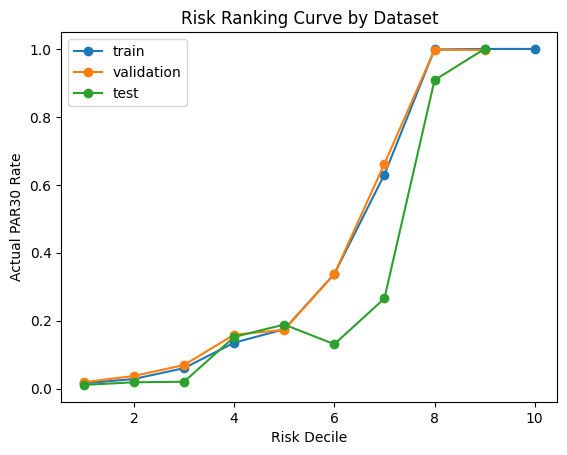

In [169]:
for d in ['train','validation','test']:

    temp = full_results[full_results['dataset']==d]

    summary = temp.groupby('risk_decile')['par30_next_month'].mean()

    plt.plot(summary.index, summary.values, marker='o', label=d)

plt.legend()
plt.xlabel("Risk Decile")
plt.ylabel("Actual PAR30 Rate")
plt.title("Risk Ranking Curve by Dataset")
plt.show()

Using this model how many defaults could have been captured for the test data

In [170]:
# df_gain = full_results.sort_values('par30_probability', ascending=False).reset_index(drop=True)
df_gain = test.sort_values('par30_probability', ascending=False).reset_index(drop=True)

In [171]:
df_gain['cum_customers'] = (df_gain.index + 1) / len(df_gain)

df_gain['cum_defaults'] = df_gain['par30_next_month'].cumsum()

total_defaults = df_gain['par30_next_month'].sum()

df_gain['cum_default_capture'] = df_gain['cum_defaults'] / total_defaults

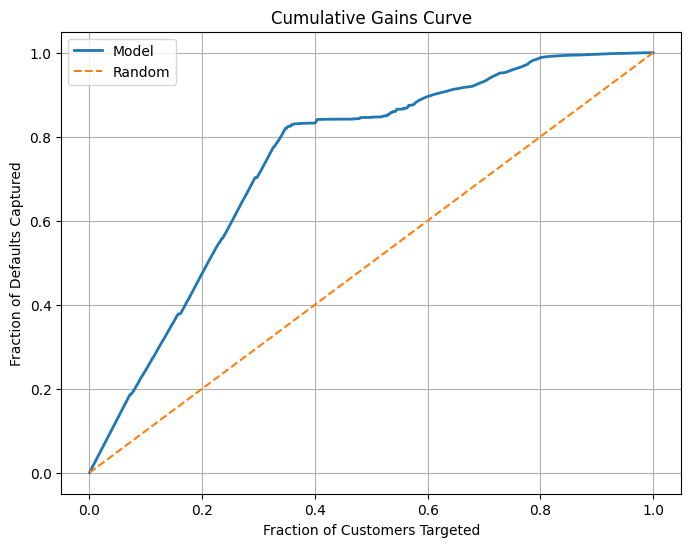

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    df_gain['cum_customers'],
    df_gain['cum_default_capture'],
    label='Model',
    linewidth=2
)

# random baseline
plt.plot([0,1],[0,1], linestyle='--', label='Random')

plt.xlabel("Fraction of Customers Targeted")
plt.ylabel("Fraction of Defaults Captured")
plt.title("Cumulative Gains Curve")
plt.legend()
plt.grid(True)

plt.show()

In [173]:
# defaults reached and missed
defaults_total = test['par30_next_month'].sum()

defaults_reached = test[
    ((test['risk_segment'] == 'High') |
    (test['risk_segment'] == 'Medium'))
    &
    (test['par30_next_month'] == 1)
]

defaults_missed = test[
    (test['risk_segment'] == 'Low') &
    (test['par30_next_month'] == 1)
]

non_defaults_reached = test[
    ((test['risk_segment'] == 'High') |
    (test['risk_segment'] == 'Medium'))
    &
    (test['par30_next_month'] == 0)
]

non_defaults = test[
    (test['risk_segment'] == 'Low') &
    (test['par30_next_month'] == 0)
]

In [174]:
defaults_reached.customer_id.nunique()

5494

In [175]:
defaults_missed.customer_id.nunique()

1687

In [176]:
non_defaults_reached.customer_id.nunique()

6917

In [177]:
non_defaults.customer_id.nunique()

10784

In [ ]:
# for january who would we have missed in December and should have reached out to
defaults_missed[defaults_missed['month']=="2025-12-01"]

In [ ]:
defaults_missed[defaults_missed['month']=="2025-12-01"]['risk_segment'].value_counts()

In [ ]:
# test[(test['month']=="2025-12-01") & (test['par30_next_month']==1.0) & (test['customer_id']==807)]
# test[(test['par30_next_month']==1.0) & (test['risk_segment']=="Low")]
test[(test['par30_next_month']==1.0) & (test['risk_segment']=="Low") & (test['customer_id']==16959)]

In [ ]:
test[(test['customer_id']==16959)]

In [ ]:
full_results[(full_results['customer_id']==16959)]

In [ ]:
# for january who would we have reached in December and should have actually reached out to
defaults_reached[defaults_reached['month']=="2025-12-01"]

In [ ]:
# test[(test['month']=="2025-12-01") & (test['par30_next_month']==1.0) & (test['customer_id']==807)]
# test[(test['par30_next_month']==1.0) & (test['risk_segment']=="High")]
test[(test['par30_next_month']==1.0) & (test['risk_segment']=="High") & (test['customer_id']==14420)]

In [ ]:
test[(test['customer_id']==14420)]

In [186]:
capture_rate = defaults_reached.shape[0] / defaults_total

print("Total defaults:", defaults_total)
print("Defaults reached (High and Medium risk):", defaults_reached.shape[0])
print("Defaults missed:", defaults_missed.shape[0])
print("Capture rate:", capture_rate)

Total defaults: 29335.0
Defaults reached (High and Medium risk): 26731
Defaults missed: 2604
Capture rate: 0.9112323163456622


In [ ]:
defaults_missed[defaults_missed['month']=="2025-12-01"]['risk_segment'].value_counts()

In [192]:
accounts_mv_query='''
SELECT
  account_id,
  customerId AS customer_id,
  status AS current_account_status,
  accountType,
  updatedAt,
  companyRegion,
  createdAt AS account_created_at
  FROM marts.accounts_mv
'''
accounts_mv_df_ch=ch_client.query_df(accounts_mv_query)

In [193]:
# expected defaults for April
# filter for payg
# account_status == current or arrears or pending_repossession
future_df = df.merge(accounts_mv_df_ch[["customer_id", "current_account_status", "accountType"]], on="customer_id", how="left")

In [194]:
future_df.accountType.value_counts()

,count
accountType,
PAYG,977584
CASH,34488
ADDON,11626


In [195]:
future_df.current_account_status.value_counts()

,count
current_account_status,
Complete,286768
Current,172978
Repossession,169478
Arrears,142540
No Deposit,92683
Write Off,46328
Pending Repossession,31553
Advance,26302
Full Deposit,19654


In [196]:
future_df = future_df[(future_df['accountType']=="PAYG") & ((future_df["current_account_status"]=="Arrears") | (future_df["current_account_status"]=="Current") | (future_df["current_account_status"]=="Pending Repossession"))]

In [197]:
future_df.customer_id.nunique()

16275

In [198]:
future_df.month.max()

Timestamp('2029-03-01 00:00:00')

In [199]:
future_df = future_df[future_df['month'] <= '2026-03-01']


In [200]:
future_df['risk_score'] = model.predict_proba(future_df[features])[:,1]

In [ ]:
def risk_segment(p):
    if p < 0.3:
        return "Low"
    elif p < 0.6:
        return "Medium"
    else:
        return "High"

future_df['risk_segment'] = future_df['risk_score'].apply(risk_segment)

In [ ]:
future_df.tail()

In [ ]:
future_df[future_df['customer_id']==7297]

In [ ]:
df[df['customer_id']==7297]

In [ ]:
future_df[future_df['customer_id']==52835]

In [ ]:
df[df['customer_id']==52835]

In [ ]:
future_df[future_df['customer_id']==173778]

In [ ]:
df[df['customer_id']==173778]

In [209]:
# get latest per customer

latest_df = (
    future_df.sort_values(['customer_id', 'month'], ascending=[True, False])
      .drop_duplicates(subset='customer_id', keep='first')
)

In [210]:
latest_df.customer_id.nunique()

12700

In [211]:
latest_df.risk_segment.value_counts()

,count
risk_segment,
Low,7505
High,3850
Medium,1345


In [212]:
high_risk = latest_df[(latest_df['risk_segment']=="High") | (latest_df['risk_segment']=="Medium")]

In [ ]:
high_risk.head()

In [215]:
# import pandas as pd
# import numpy as np
# import shap
# import matplotlib.pyplot as plt
# import textwrap
# from matplotlib.colors import LinearSegmentedColormap

# # assume:
# # model = your trained xgboost model
# # X_val = validation dataset used for evaluation

# # -------------------------
# # 1) GAIN IMPORTANCE
# # -------------------------
# model=model
# X_val = X_test
# y_val = y_test
# gain_dict = model.get_booster().get_score(importance_type="gain")

# gain_df = (
#     pd.DataFrame(gain_dict.items(), columns=["feature", "gain"])
#     .sort_values("gain", ascending=False)
# )

# print("Top features by Gain")
# print(gain_df.head(20))

# set2 = sns.color_palette("Set2", n_colors=8)
# cmap = LinearSegmentedColormap.from_list("set2_bar", set2)


# # Plot gain
# plt.figure(figsize=(8,6))
# top_gain = gain_df.head(20).sort_values("gain")

# palette = sns.color_palette("Set2", n_colors=len(top_gain))

# plt.barh(top_gain["feature"], top_gain["gain"], color=palette)
# plt.xlabel("Gain")
# plt.title("Top Features by Gain")
# plt.tight_layout()
# # plt.savefig('/content/drive/MyDrive/Unified Model/top_features_by_gain.png')
# plt.show()


# # -------------------------
# # 2) SHAP IMPORTANCE
# # -------------------------
# explainer = shap.Explainer(model, X_val)
# shap_values = explainer(X_val)

# mean_abs_shap = pd.DataFrame({
#     "feature": X_val.columns,
#     "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
# }).sort_values("mean_abs_shap", ascending=False)

# print("\nTop features by SHAP")
# print(mean_abs_shap.head(20))


# # Plot SHAP bar
# plt.figure(figsize=(10, 8))
# wrapped = ['\n'.join(textwrap.wrap(c, 20)) for c in X_val.columns]
# X_wrap = X_val.copy()
# X_wrap.columns = wrapped
# # shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
# # shap.summary_plot(shap_values, X_val, plot_type="bar")
# shap.summary_plot(shap_values, X_wrap, plot_type="bar", show=False, cmap=cmap)
# plt.title("SHAP Feature Importance")
# plt.xlabel("Mean SHAP value")
# plt.tight_layout()
# # plt.savefig("/content/drive/MyDrive/Unified Model/shap_features_gain.png")
# plt.show()

# # -------------------------
# # 3) Combine Gain + SHAP
# # -------------------------
# comparison = pd.merge(
#     gain_df,
#     mean_abs_shap,
#     on="feature",
#     how="outer"
# ).fillna(0).sort_values("mean_abs_shap", ascending=False)

# print("\nCombined importance")
# print(comparison.head(20))


In [216]:
# import shap
# import matplotlib.pyplot as plt
# import textwrap

# # function to wrap long labels
# def wrap_names(names, width=18):
#     return ['\n'.join(textwrap.wrap(str(n), width)) for n in names]

# # copy so the model input is untouched
# X_plot = X_val.copy()
# X_plot.columns = wrap_names(X_plot.columns, width=20)

# set2 = sns.color_palette("Set2", n_colors=8)
# cmap = LinearSegmentedColormap.from_list("set2_grad", set2)

# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_val)

# plt.figure(figsize=(20, 20))  # give the plot more room
# shap.summary_plot(shap_values, X_plot, show=False, cmap=cmap)

# plt.title("Direction of Feature Impact on Risk")
# plt.tight_layout()
# # plt.savefig("/content/drive/MyDrive/Unified Model/direction_of_impact_wrapped.png")
# plt.show()
